# Prediction Cup — Analysis Notebook

All helper functions return DataFrames with no hardcoded teams or players.  
Run **Section 1** once to load the DB, then call any helper in later sections.

---

### Data sources & granularity
| Source | Fixtures | Stats available | Granularity |
|---|---|---|---|
| API-Football | 2022 WC (numeric IDs) | Shots, fouls, cards, offsides, corners, possession, passes, halftime scores | Full-game + **halftime split** |
| FBref/soccerdata | 2026 WC (hash IDs) | Fouls, cards, offsides (misc) · Shots, SoT, SoT% (shooting) · Full player summary | Full-game only |

> **Note on second-half stats:** Only API-Football 2022 WC fixtures have halftime scores, so `home_goals_2h` / `away_goals_2h` are populated for those rows only.  
> For card/shot timing ("in the second half") there is no event-level data in the current dataset.
> All team/player statistics are **full-game totals**.

---
## Section 1 — Imports, DB helpers & normalization
**Run this cell first every session.**

In [1]:
import json
import re
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_rows", 60)

DB_PATH = Path("../prediction_cup.db")

GRANULARITY_NOTE = (
    "[granularity: full_game] "
    "All statistics are full-game totals. "
    "No per-half splits are available in the current dataset "
    "(halftime goal splits exist for 2022 WC / API-Football fixtures only)."
)


# ── Low-level helpers ────────────────────────────────────────────────────────

def _conn():
    return sqlite3.connect(DB_PATH)


def _gv(payload: dict, *keys):
    """Return the first non-None value found among the given keys."""
    for k in keys:
        v = payload.get(k)
        if v is not None:
            return v
    return None


def _pct(v):
    """Convert '47%' → 47.0; pass numerics through; return None for nulls."""
    if v is None:
        return None
    if isinstance(v, str):
        v = v.strip().replace("%", "")
    try:
        result = float(v)
        return None if np.isnan(result) else result
    except (ValueError, TypeError):
        return None


def _int(v):
    """Safe int conversion; returns None for null/NaN."""
    try:
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return None
        return int(v)
    except (TypeError, ValueError):
        return None


print("Helpers loaded.")

Helpers loaded.


---
## Section 2 — DB loading functions

In [2]:
def load_fixtures() -> pd.DataFrame:
    """
    Load and normalize all fixtures from raw_fixtures.

    Columns
    -------
    fixture_id, match_date, home_team, away_team,
    home_goals_ft, away_goals_ft, total_goals, btts,
    home_goals_ht, away_goals_ht,   ← populated for 2022 WC (API-Football) only
    home_goals_2h, away_goals_2h,   ← populated for 2022 WC (API-Football) only
    winner ("home"/"away"/"draw"),
    venue, season, round, source ("api_football" | "fbref")
    """
    with _conn() as conn:
        raw = pd.read_sql_query("SELECT * FROM raw_fixtures", conn)

    records = []
    for _, row in raw.iterrows():
        try:
            payload = json.loads(row["raw_payload"])
        except (json.JSONDecodeError, TypeError):
            continue

        fid = row["fixture_id"]

        # ── API-Football format (2022 WC, numeric fixture IDs) ───────────────
        if "fixture" in payload and "teams" in payload:
            teams  = payload.get("teams", {})
            goals  = payload.get("goals", {})
            score  = payload.get("score", {})
            ht     = (score.get("halftime") or {})

            home_ft = _int(goals.get("home"))
            away_ft = _int(goals.get("away"))
            home_ht = _int(ht.get("home"))
            away_ht = _int(ht.get("away"))
            home_2h = (home_ft - home_ht) if (home_ft is not None and home_ht is not None) else None
            away_2h = (away_ft - away_ht) if (away_ft is not None and away_ht is not None) else None

            home_winner = teams.get("home", {}).get("winner")
            away_winner = teams.get("away", {}).get("winner")
            winner = "home" if home_winner else ("away" if away_winner else "draw")

            records.append({
                "fixture_id":    fid,
                "match_date":    payload["fixture"].get("date", "")[:10],
                "home_team":     teams.get("home", {}).get("name"),
                "away_team":     teams.get("away", {}).get("name"),
                "home_goals_ft": home_ft,
                "away_goals_ft": away_ft,
                "home_goals_ht": home_ht,
                "away_goals_ht": away_ht,
                "home_goals_2h": home_2h,
                "away_goals_2h": away_2h,
                "total_goals":   (home_ft + away_ft) if (home_ft is not None and away_ft is not None) else None,
                "btts":          (home_ft > 0 and away_ft > 0) if (home_ft is not None and away_ft is not None) else None,
                "winner":        winner,
                "venue":         payload["fixture"].get("venue", {}).get("name"),
                "season":        payload.get("league", {}).get("season"),
                "round":         payload.get("league", {}).get("round"),
                "source":        "api_football",
            })

        # ── FBref format (2026 WC, hash fixture IDs) ─────────────────────────
        elif "home_team" in payload or "game" in payload:
            raw_score   = str(payload.get("score") or "").strip()
            score_parts = re.split(r"[\u2013\u2014\-]", raw_score)  # em-dash, en-dash, hyphen
            home_ft = away_ft = None
            if len(score_parts) == 2:
                try:
                    home_ft = int(score_parts[0].strip())
                    away_ft = int(score_parts[1].strip())
                except ValueError:
                    pass

            if home_ft is not None and away_ft is not None:
                winner = "home" if home_ft > away_ft else ("away" if away_ft > home_ft else "draw")
            else:
                winner = None

            records.append({
                "fixture_id":    fid,
                "match_date":    str(payload.get("date") or row.get("match_date") or "")[:10],
                "home_team":     payload.get("home_team") or row.get("home_team"),
                "away_team":     payload.get("away_team") or row.get("away_team"),
                "home_goals_ft": home_ft,
                "away_goals_ft": away_ft,
                "home_goals_ht": None,
                "away_goals_ht": None,
                "home_goals_2h": None,
                "away_goals_2h": None,
                "total_goals":   (home_ft + away_ft) if (home_ft is not None and away_ft is not None) else None,
                "btts":          (home_ft > 0 and away_ft > 0) if (home_ft is not None and away_ft is not None) else None,
                "winner":        winner,
                "venue":         payload.get("venue"),
                "season":        payload.get("season"),
                "round":         payload.get("round"),
                "source":        "fbref",
            })

    df = pd.DataFrame(records)
    if df.empty:
        return df
    df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")
    df = df.sort_values("match_date").reset_index(drop=True)
    return df

In [3]:
def load_team_stats() -> pd.DataFrame:
    """
    Load and normalize team statistics from raw_team_stats.

    Merges misc stats (fouls/cards/offsides) with shooting stats (shots/SoT)
    for the same (fixture_id, team_name) pair where both are available.

    Columns
    -------
    fixture_id, team_name,
    shots_on_target, shots_total, shots_off_target, shots_blocked,
    shots_inside_box, shots_outside_box, shots_sot_pct,
    fouls, yellow_cards, red_cards, offsides, corners,
    possession_pct, goalkeeper_saves,
    passes_total, passes_accurate, passes_pct,
    goals_for, goals_against, result (W/D/L), opponent,
    source, has_shots (bool)

    Granularity: full_game for all rows.
    """
    print(GRANULARITY_NOTE)

    with _conn() as conn:
        raw = pd.read_sql_query("SELECT * FROM raw_team_stats", conn)

    misc_rows  = {}   # key: (fixture_id, team_name) → dict
    shoot_rows = {}   # key: (fixture_id, team_name) → dict

    for _, row in raw.iterrows():
        fid = row["fixture_id"]
        tid = str(row["team_id"])
        is_shooting = tid.endswith("__shooting")
        base_tid    = tid.replace("__shooting", "").strip()

        try:
            payload = json.loads(row["raw_payload"])
        except (json.JSONDecodeError, TypeError):
            continue

        # ── API-Football format ──────────────────────────────────────────────
        if "statistics" in payload and isinstance(payload["statistics"], list):
            team_obj  = payload.get("team", {})
            team_name = team_obj.get("name") if isinstance(team_obj, dict) else str(team_obj)
            sm        = {s["type"]: s["value"] for s in payload["statistics"]}

            misc_rows[(fid, team_name)] = {
                "fixture_id":         fid,
                "team_name":          team_name,
                "shots_on_target":    _int(sm.get("Shots on Goal")),
                "shots_total":        _int(sm.get("Total Shots")),
                "shots_off_target":   _int(sm.get("Shots off Goal")),
                "shots_blocked":      _int(sm.get("Blocked Shots")),
                "shots_inside_box":   _int(sm.get("Shots insidebox")),
                "shots_outside_box":  _int(sm.get("Shots outsidebox")),
                "shots_sot_pct":      None,
                "fouls":              _int(sm.get("Fouls")),
                "yellow_cards":       _int(sm.get("Yellow Cards")),
                "red_cards":          _int(sm.get("Red Cards")),
                "offsides":           _int(sm.get("Offsides")),
                "corners":            _int(sm.get("Corner Kicks")),
                "possession_pct":     _pct(sm.get("Ball Possession")),
                "goalkeeper_saves":   _int(sm.get("Goalkeeper Saves")),
                "passes_total":       _int(sm.get("Total passes")),
                "passes_accurate":    _int(sm.get("Passes accurate")),
                "passes_pct":         _pct(sm.get("Passes %")),
                "goals_for":          None,
                "goals_against":      None,
                "result":             None,
                "opponent":           None,
                "pk_won":             None,
                "pk_conceded":        None,
                "second_yellow":      None,
                "source":             "api_football",
                }

        # ── FBref format (clean keys after pipeline fix) ─────────────────────
        else:
            team_name = str(payload.get("team") or base_tid).strip()
            # Validate — skip any remaining corrupted rows
            if not team_name or len(team_name) > 100 or "\n" in team_name:
                continue

            if is_shooting:
                shoot_rows[(fid, team_name)] = {
                    "shots_on_target":   _int(payload.get("Standard_SoT")),
                    "shots_total":       _int(payload.get("Standard_Sh")),
                    "shots_sot_pct":     _pct(payload.get("Standard_SoT%")),
                    "shots_off_target":  None,
                    "shots_blocked":     None,
                    "shots_inside_box":  None,
                    "shots_outside_box": None,
                    "pk_attempted":      _int(payload.get("Standard_PKatt")),
                }
            else:
                misc_rows[(fid, team_name)] = {
                    "fixture_id":         fid,
                    "team_name":          team_name,
                    "shots_on_target":    None,
                    "shots_total":        None,
                    "shots_off_target":   None,
                    "shots_blocked":      None,
                    "shots_inside_box":   None,
                    "shots_outside_box":  None,
                    "shots_sot_pct":      None,
                    "fouls":              _int(payload.get("Performance_Fls")),
                    "yellow_cards":       _int(payload.get("Performance_CrdY")),
                    "red_cards":          _int(payload.get("Performance_CrdR")),
                    "offsides":           _int(payload.get("Performance_Off")),
                    "corners":            None,
                    "possession_pct":     None,
                    "goalkeeper_saves":   None,
                    "passes_total":       None,
                    "passes_accurate":    None,
                    "passes_pct":         None,
                    "goals_for":          _int(payload.get("GF")),
                    "goals_against":      _int(payload.get("GA")),
                    "result":             payload.get("result"),  # W/D/L
                    "opponent":           payload.get("opponent"),
                    "pk_won":             _int(payload.get("Performance_PKwon")),
                    "pk_conceded":        _int(payload.get("Performance_PKcon")),
                    "second_yellow":      _int(payload.get("Performance_2CrdY")),
                    "source":             "fbref",
                }

    # Merge misc + shooting for FBref rows
    records = []
    all_keys = set(misc_rows) | set(shoot_rows)
    for key in all_keys:
        misc  = dict(misc_rows.get(key) or {})
        shoot = shoot_rows.get(key, {})
        # Fill in shot/penalty fields from shooting row where misc row has None
        for field in ("shots_on_target", "shots_total", "shots_sot_pct",
                      "shots_off_target", "shots_blocked",
                      "shots_inside_box", "shots_outside_box",
                      "pk_attempted"):
            if misc.get(field) is None and shoot.get(field) is not None:
                misc[field] = shoot[field]
        if misc:
            misc["has_shots"] = misc.get("shots_total") is not None
            records.append(misc)

    df = pd.DataFrame(records) if records else pd.DataFrame()
    return df

In [4]:
def load_player_stats() -> pd.DataFrame:
    """
    Load and normalize player statistics from raw_player_stats.

    Columns
    -------
    fixture_id, player_name, team_name, position, minutes,
    shots_total, shots_on_target,
    goals, assists,
    yellow_cards, red_cards,
    fouls_committed, fouls_drawn, offsides,
    passes_total, key_passes,
    tackles, interceptions, blocks,
    dribbles_attempted, dribbles_successful,
    duels_total, duels_won,
    goalkeeper_saves,
    rating, is_substitute, source

    Granularity: full_game for all rows.
    """
    print(GRANULARITY_NOTE)

    with _conn() as conn:
        raw = pd.read_sql_query("SELECT * FROM raw_player_stats", conn)

    records = []
    for _, row in raw.iterrows():
        fid = row["fixture_id"]
        try:
            payload = json.loads(row["raw_payload"])
        except (json.JSONDecodeError, TypeError):
            continue

        # ── API-Football format ──────────────────────────────────────────────
        if "statistics" in payload and isinstance(payload["statistics"], list):
            player_obj  = payload.get("player", {})
            player_name = player_obj.get("name") if isinstance(player_obj, dict) else str(player_obj)
            st          = payload["statistics"][0] if payload["statistics"] else {}

            games   = st.get("games", {}) or {}
            shots   = st.get("shots", {}) or {}
            goals   = st.get("goals", {}) or {}
            passes  = st.get("passes", {}) or {}
            tackles = st.get("tackles", {}) or {}
            duels   = st.get("duels", {}) or {}
            drib    = st.get("dribbles", {}) or {}
            fouls   = st.get("fouls", {}) or {}
            cards   = st.get("cards", {}) or {}

            records.append({
                "fixture_id":            fid,
                "player_name":           player_name,
                "team_name":             None,  # not available in API-Football player payload
                "position":              games.get("position"),
                "minutes":               _int(games.get("minutes")),
                "shots_total":           _int(shots.get("total")),
                "shots_on_target":       _int(shots.get("on")),
                "goals":                 _int(goals.get("total")),
                "assists":               _int(goals.get("assists")),
                "yellow_cards":          _int(cards.get("yellow")),
                "red_cards":             _int(cards.get("red")),
                "fouls_committed":       _int(fouls.get("committed")),
                "fouls_drawn":           _int(fouls.get("drawn")),
                "offsides":              _int(st.get("offsides")),
                "passes_total":          _int(passes.get("total")),
                "key_passes":            _int(passes.get("key")),
                "tackles":               _int(tackles.get("total")),
                "interceptions":         _int(tackles.get("interceptions")),
                "blocks":                _int(tackles.get("blocks")),
                "dribbles_attempted":    _int(drib.get("attempts")),
                "dribbles_successful":   _int(drib.get("success")),
                "duels_total":           _int(duels.get("total")),
                "duels_won":             _int(duels.get("won")),
                "goalkeeper_saves":      _int(goals.get("saves")),
                "rating":                _pct(games.get("rating")),
                "is_substitute":         bool(games.get("substitute")),
                "source":                "api_football",
            })

        # ── FBref format ─────────────────────────────────────────────────────
        else:
            player_name = payload.get("player")
            team_name   = payload.get("team")

            # Reject any remaining corrupted rows
            if not player_name or not isinstance(player_name, str) or "\n" in player_name or len(player_name) > 200:
                continue

            def fp(*keys):
                """Get value with primary key (clean) then fallback tuple-string key."""
                return _gv(payload, *keys)

            records.append({
                "fixture_id":            fid,
                "player_name":           player_name.strip(),
                "team_name":             str(team_name).strip() if team_name else None,
                "position":              fp("pos", "('pos', '')"),
                "minutes":               _int(fp("min", "('min', '')")),
                "shots_total":           _int(fp("Performance_Sh",   "('Performance', 'Sh')")),
                "shots_on_target":       _int(fp("Performance_SoT",  "('Performance', 'SoT')")),
                "goals":                 _int(fp("Performance_Gls",  "('Performance', 'Gls')")),
                "assists":               _int(fp("Performance_Ast",  "('Performance', 'Ast')")),
                "yellow_cards":          _int(fp("Performance_CrdY", "('Performance', 'CrdY')")),
                "red_cards":             _int(fp("Performance_CrdR", "('Performance', 'CrdR')")),
                "fouls_committed":       _int(fp("Performance_Fls",  "('Performance', 'Fls')")),
                "fouls_drawn":           _int(fp("Performance_Fld",  "('Performance', 'Fld')")),
                "offsides":              _int(fp("Performance_Off",  "('Performance', 'Off')")),
                "passes_total":          None,
                "key_passes":            None,
                "tackles":               _int(fp("Performance_TklW", "('Performance', 'TklW')")),
                "interceptions":         _int(fp("Performance_Int",  "('Performance', 'Int')")),
                "blocks":                None,
                "dribbles_attempted":    None,
                "dribbles_successful":   None,
                "duels_total":           None,
                "duels_won":             None,
                "goalkeeper_saves":      None,
                "rating":                None,
                "is_substitute":         None,
                "source":                "fbref",
            })

    df = pd.DataFrame(records) if records else pd.DataFrame()
    return df

In [5]:
def load_weather() -> pd.DataFrame:
    """
    Load weather data from raw_weather.

    Columns
    -------
    fixture_id, venue_city, match_date, data_type ("historical"|"forecast"),
    temp_max_c, temp_min_c, precipitation_mm, wind_speed_max_kmh,
    precip_probability_pct,
    hourly_times, hourly_temp_c, hourly_precip_mm,
    hourly_wind_kmh, hourly_precip_prob
    """
    with _conn() as conn:
        raw = pd.read_sql_query("SELECT * FROM raw_weather", conn)

    records = []
    for _, row in raw.iterrows():
        try:
            payload = json.loads(row["raw_payload"])
        except (json.JSONDecodeError, TypeError):
            continue

        daily  = payload.get("daily", {}) or {}
        hourly = payload.get("hourly", {}) or {}

        def first(lst):
            return lst[0] if isinstance(lst, list) and lst else None

        records.append({
            "fixture_id":             row["fixture_id"],
            "venue_city":             row.get("venue_city"),
            "match_date":             row.get("match_date"),
            "data_type":              row.get("data_type"),
            "temp_max_c":             first(daily.get("temperature_2m_max")),
            "temp_min_c":             first(daily.get("temperature_2m_min")),
            "precipitation_mm":       first(daily.get("precipitation_sum")),
            "wind_speed_max_kmh":     first(daily.get("windspeed_10m_max")),
            "precip_probability_pct": first(daily.get("precipitation_probability_max")),
            "hourly_times":           hourly.get("time"),
            "hourly_temp_c":          hourly.get("temperature_2m"),
            "hourly_precip_mm":       hourly.get("precipitation"),
            "hourly_wind_kmh":        hourly.get("windspeed_10m"),
            "hourly_precip_prob":     hourly.get("precipitation_probability"),
        })

    return pd.DataFrame(records) if records else pd.DataFrame()


def load_market_odds() -> pd.DataFrame:
    """Load market odds from raw_market_odds (currently mostly stub data)."""
    with _conn() as conn:
        raw = pd.read_sql_query("SELECT * FROM raw_market_odds", conn)

    records = []
    for _, row in raw.iterrows():
        try:
            payload = json.loads(row["raw_payload"])
        except (json.JSONDecodeError, TypeError):
            continue
        for line in payload.get("lines", []):
            records.append({
                "fixture_id":  row["fixture_id"],
                "market_type": row["market_type"],
                "timestamp":   row["timestamp"],
                "line":        line.get("line"),
                "odds_yes":    line.get("odds_yes"),
                "odds_no":     line.get("odds_no"),
                "bookmaker":   payload.get("bookmaker"),
            })

    return pd.DataFrame(records) if records else pd.DataFrame()

---
## Section 3 — Load all DataFrames
**Run this cell to populate `df_fixtures`, `df_team_stats`, `df_player_stats`, `df_weather`, `df_market_odds`.**  
Re-run after the ingest pipeline updates the DB.

In [6]:
df_fixtures     = load_fixtures()
df_team_stats   = load_team_stats()
df_player_stats = load_player_stats()
df_weather      = load_weather()
df_market_odds  = load_market_odds()

print(f"\n  fixtures     : {len(df_fixtures):>4} rows  |  {df_fixtures['source'].value_counts().to_dict()}")
print(f"  team_stats   : {len(df_team_stats):>4} rows  |  shots available: {df_team_stats['has_shots'].sum()} rows")
print(f"  player_stats : {len(df_player_stats):>4} rows")
print(f"  weather      : {len(df_weather):>4} rows")
print(f"  market_odds  : {len(df_market_odds):>4} rows")

print("\nDate range:", df_fixtures["match_date"].min().date(), "→", df_fixtures["match_date"].max().date())
print("Teams:", sorted(set(df_fixtures["home_team"].dropna()) | set(df_fixtures["away_team"].dropna())))

[granularity: full_game] All statistics are full-game totals. No per-half splits are available in the current dataset (halftime goal splits exist for 2022 WC / API-Football fixtures only).
[granularity: full_game] All statistics are full-game totals. No per-half splits are available in the current dataset (halftime goal splits exist for 2022 WC / API-Football fixtures only).

  fixtures     :   24 rows  |  {'fbref': 24}
  team_stats   :   16 rows  |  shots available: 16 rows
  player_stats :  250 rows
  weather      :   43 rows
  market_odds  :    0 rows

Date range: 2026-06-12 → 2026-06-21
Teams: ['Australia', 'Belgium', 'Brazil', 'Cabo Verde', 'Curaçao', "Côte d'Ivoire", 'Ecuador', 'Egypt', 'Germany', 'Haiti', 'IR Iran', 'Japan', 'Morocco', 'Netherlands', 'New Zealand', 'Paraguay', 'Saudi Arabia', 'Scotland', 'Spain', 'Sweden', 'Tunisia', 'Türkiye', 'United States', 'Uruguay']


---
## Section 4 — Team-level helpers

In [7]:
def _team_fixtures(team_name: str) -> pd.DataFrame:
    """All completed fixtures involving a team, sorted newest-first."""
    mask = (df_fixtures["home_team"] == team_name) | (df_fixtures["away_team"] == team_name)
    df   = df_fixtures[mask].copy()
    df   = df[df["home_goals_ft"].notna() | df["away_goals_ft"].notna()]

    # Perspective columns relative to the focal team
    df["is_home"]        = df["home_team"] == team_name
    df["opponent"]       = df.apply(lambda r: r["away_team"] if r["is_home"] else r["home_team"], axis=1)
    df["goals_scored"]   = df.apply(lambda r: r["home_goals_ft"] if r["is_home"] else r["away_goals_ft"], axis=1)
    df["goals_conceded"] = df.apply(lambda r: r["away_goals_ft"] if r["is_home"] else r["home_goals_ft"], axis=1)
    df["goals_2h"]       = df.apply(lambda r: r["home_goals_2h"] if r["is_home"] else r["away_goals_2h"], axis=1)
    df["goals_2h_conceded"] = df.apply(lambda r: r["away_goals_2h"] if r["is_home"] else r["home_goals_2h"], axis=1)

    def _result(r):
        gs, gc = r["goals_scored"], r["goals_conceded"]
        if gs is None or gc is None:
            return None
        return "W" if gs > gc else ("L" if gs < gc else "D")

    df["result"] = df.apply(_result, axis=1)
    return df.sort_values("match_date", ascending=False).reset_index(drop=True)


def get_team_history(team_name: str, n: int = 10) -> pd.DataFrame:
    """
    Last N completed matches for a team, merged with available team stats.

    Parameters
    ----------
    team_name : str   e.g. "Brazil"
    n         : int   number of most-recent games (default 10)

    Returns
    -------
    DataFrame with columns:
        match_date, opponent, result, goals_scored, goals_conceded,
        goals_2h (2nd-half goals — NaN for FBref fixtures),
        shots_on_target, shots_total, shots_sot_pct,
        fouls, yellow_cards, red_cards, offsides, corners,
        possession_pct, goalkeeper_saves,
        venue, round, season, source, fixture_id

    Granularity: full_game. goals_2h populated for 2022 WC only.
    """
    print(GRANULARITY_NOTE)

    fx = _team_fixtures(team_name).head(n)

    # Join team stats where available
    ts = df_team_stats[df_team_stats["team_name"] == team_name].copy()
    stat_cols = [
        "fixture_id", "shots_on_target", "shots_total", "shots_sot_pct",
        "shots_off_target", "shots_blocked", "shots_inside_box", "shots_outside_box",
        "fouls", "yellow_cards", "red_cards", "offsides", "corners",
        "possession_pct", "goalkeeper_saves", "passes_total", "passes_accurate",
    ]
    ts_sub = ts[[c for c in stat_cols if c in ts.columns]]

    merged = fx.merge(ts_sub, on="fixture_id", how="left")

    # For FBref rows that have goals_for/goals_against in team_stats but not fixture
    # (happens when fixture payload has no score yet), backfill from team_stats
    if "goals_for" in ts.columns:
        ts_gf = ts[["fixture_id", "goals_for", "goals_against"]].dropna(subset=["goals_for"])
        merged = merged.merge(ts_gf, on="fixture_id", how="left")
        merged["goals_scored"]   = merged["goals_scored"].combine_first(merged["goals_for"])
        merged["goals_conceded"] = merged["goals_conceded"].combine_first(merged["goals_against"])
        merged = merged.drop(columns=["goals_for", "goals_against"], errors="ignore")

    out_cols = [
        "match_date", "opponent", "result", "goals_scored", "goals_conceded",
        "goals_2h", "goals_2h_conceded",
        "shots_on_target", "shots_total", "shots_sot_pct",
        "fouls", "yellow_cards", "red_cards", "offsides", "corners",
        "possession_pct", "goalkeeper_saves",
        "venue", "round", "season", "source", "fixture_id",
    ]
    return merged[[c for c in out_cols if c in merged.columns]].reset_index(drop=True)

In [8]:
def compare_teams_stat(
    team1: str,
    team2: str,
    stat: str,
    n: int = 10,
) -> pd.DataFrame:
    """
    Side-by-side per-game comparison of two teams for any stat.

    Useful for:
      - "Will Team1 commit more fouls than Team2?"     → stat="fouls"
      - "Will Team1 have more SoT than Team2?"         → stat="shots_on_target"
      - "Will Team1 be offside 2+ times?"              → stat="offsides"
      - "Will Team1 receive a card?"                   → stat="yellow_cards"

    Parameters
    ----------
    team1, team2 : str   team names
    stat         : str   any column in df_team_stats (fouls, yellow_cards,
                         red_cards, offsides, shots_on_target, shots_total,
                         corners, possession_pct, goalkeeper_saves, …)
    n            : int   last N games per team

    Returns
    -------
    Dict with keys:
      "team1_history"  : DataFrame  — last N games + stat value for team1
      "team2_history"  : DataFrame  — last N games + stat value for team2
      "summary"        : DataFrame  — mean / median / std / min / max per team
      "granularity"    : str
    """
    print(GRANULARITY_NOTE)

    def _team_stat_history(team_name, s, num):
        h = get_team_history(team_name, n=num)
        cols = ["match_date", "opponent", "result", "goals_scored", "goals_conceded"]
        if s in h.columns:
            cols.append(s)
        return h[cols].copy()

    h1 = _team_stat_history(team1, stat, n)
    h2 = _team_stat_history(team2, stat, n)

    def _summary(df, name):
        if stat not in df.columns:
            return pd.DataFrame({"team": [name], stat: [None]})
        s = df[stat].dropna()
        return pd.DataFrame({
            "team":   [name],
            "games":  [len(s)],
            "mean":   [round(s.mean(), 2) if len(s) else None],
            "median": [s.median() if len(s) else None],
            "std":    [round(s.std(), 2) if len(s) else None],
            "min":    [s.min() if len(s) else None],
            "max":    [s.max() if len(s) else None],
        })

    summary = pd.concat([_summary(h1, team1), _summary(h2, team2)], ignore_index=True)

    return {
        "team1_history": h1,
        "team2_history": h2,
        "summary":       summary,
        "granularity":   "full_game",
    }


def get_goals_history(
    team1: str = None,
    team2: str = None,
    n: int = 20,
) -> pd.DataFrame:
    """
    Fixture history with goal breakdown, optionally filtered to one or two teams.

    Useful for:
      - "Will both teams score AND the match have 3+ total goals?"  (BTTS + over 2.5)
      - "Will Team1 score in the second half?"   (goals_2h column — 2022 WC only)

    Parameters
    ----------
    team1, team2 : str or None   filter to fixtures involving these teams
    n            : int           max rows to return

    Returns
    -------
    DataFrame with columns:
        match_date, home_team, away_team,
        home_goals_ft, away_goals_ft, total_goals,
        home_goals_ht, away_goals_ht,
        home_goals_2h, away_goals_2h,
        btts, winner, venue, round, season, source, fixture_id

    Note: home_goals_ht/2h columns are NaN for FBref (2026 WC) fixtures.
    """
    df = df_fixtures.copy()
    df = df[df["home_goals_ft"].notna() | df["away_goals_ft"].notna()]

    if team1 and team2:
        mask = (
            ((df["home_team"] == team1) & (df["away_team"] == team2)) |
            ((df["home_team"] == team2) & (df["away_team"] == team1))
        )
        df = df[mask]
    elif team1:
        df = df[(df["home_team"] == team1) | (df["away_team"] == team1)]
    elif team2:
        df = df[(df["home_team"] == team2) | (df["away_team"] == team2)]

    cols = [
        "match_date", "home_team", "away_team",
        "home_goals_ft", "away_goals_ft", "total_goals",
        "home_goals_ht", "away_goals_ht",
        "home_goals_2h", "away_goals_2h",
        "btts", "winner", "venue", "round", "season", "source", "fixture_id",
    ]
    return df[[c for c in cols if c in df.columns]].sort_values("match_date", ascending=False).head(n).reset_index(drop=True)

In [9]:
def get_head_to_head(team1: str, team2: str) -> pd.DataFrame:
    """
    All historical meetings between two teams.

    Parameters
    ----------
    team1, team2 : str

    Returns
    -------
    DataFrame with columns:
        match_date, home_team, away_team,
        home_goals_ft, away_goals_ft, total_goals, btts,
        winner, venue, round, season, source
    """
    mask = (
        ((df_fixtures["home_team"] == team1) & (df_fixtures["away_team"] == team2)) |
        ((df_fixtures["home_team"] == team2) & (df_fixtures["away_team"] == team1))
    )
    df = df_fixtures[mask].copy()
    df = df[df["home_goals_ft"].notna() | df["away_goals_ft"].notna()]

    cols = [
        "match_date", "home_team", "away_team",
        "home_goals_ft", "away_goals_ft", "total_goals", "btts",
        "winner", "venue", "round", "season", "source",
    ]
    return df[[c for c in cols if c in df.columns]].sort_values("match_date", ascending=False).reset_index(drop=True)


def get_team_form(team_name: str, n: int = 10) -> pd.DataFrame:
    """
    Last N matches with W/D/L flag and rolling offensive/defensive averages.

    Useful for: "Will Team1 win?" context, overall form assessment.

    Returns
    -------
    DataFrame with columns:
        match_date, opponent, result, goals_scored, goals_conceded,
        points (3/1/0),
        rolling_goals_scored_avg  (3-game),
        rolling_goals_conceded_avg (3-game),
        source
    """
    fx = _team_fixtures(team_name).head(n)
    if fx.empty:
        return fx

    fx = fx.sort_values("match_date").copy()  # chronological for rolling
    fx["points"] = fx["result"].map({"W": 3, "D": 1, "L": 0})
    fx["rolling_goals_scored_avg"]   = fx["goals_scored"].rolling(3, min_periods=1).mean().round(2)
    fx["rolling_goals_conceded_avg"] = fx["goals_conceded"].rolling(3, min_periods=1).mean().round(2)
    fx = fx.sort_values("match_date", ascending=False)  # back to newest-first

    cols = [
        "match_date", "opponent", "result", "goals_scored", "goals_conceded",
        "points", "rolling_goals_scored_avg", "rolling_goals_conceded_avg",
        "venue", "round", "source",
    ]
    return fx[[c for c in cols if c in fx.columns]].reset_index(drop=True)


def get_defensive_record(team_name: str, n: int = 10) -> pd.DataFrame:
    """
    A team's defensive stats: shots conceded, SoT conceded, goals conceded.
    Used as opponent context when evaluating player shot questions.

    Useful for:
      - Opponent side of "Will Player1 have at least 1 SoT?"
      - "Will Team2 have 3+ shots on target?" (opponent defensive leniency)

    Parameters
    ----------
    team_name : str   the DEFENDING team
    n         : int   last N games

    Returns
    -------
    DataFrame with per-game:
        match_date, opponent (attacker), goals_conceded,
        shots_on_target_conceded, shots_total_conceded,
        source, fixture_id

    Plus .attrs["summary"] with mean/median/std for shot columns.

    Granularity: full_game.
    """
    print(GRANULARITY_NOTE)

    fx = _team_fixtures(team_name).head(n)
    if fx.empty:
        return fx

    # The opponent's shot stats = SoT conceded by team_name
    opp_stats_list = []
    for _, row in fx.iterrows():
        opp = row["opponent"]
        fid = row["fixture_id"]
        opp_ts = df_team_stats[
            (df_team_stats["fixture_id"] == fid) &
            (df_team_stats["team_name"] == opp)
        ]
        sot_conceded  = opp_ts["shots_on_target"].values[0] if not opp_ts.empty and "shots_on_target" in opp_ts.columns else None
        sh_conceded   = opp_ts["shots_total"].values[0] if not opp_ts.empty and "shots_total" in opp_ts.columns else None
        opp_stats_list.append({
            "match_date":               row["match_date"],
            "opponent":                 opp,
            "goals_conceded":           row["goals_conceded"],
            "shots_on_target_conceded": sot_conceded,
            "shots_total_conceded":     sh_conceded,
            "source":                   row["source"],
            "fixture_id":               fid,
        })

    df = pd.DataFrame(opp_stats_list)

    summary_cols = ["goals_conceded", "shots_on_target_conceded", "shots_total_conceded"]
    summary = df[[c for c in summary_cols if c in df.columns]].agg(["mean", "median", "std"]).round(2)
    df.attrs["summary"] = summary

    return df.sort_values("match_date", ascending=False).reset_index(drop=True)

---
## Section 5 — Player-level helpers

In [10]:
def get_player_history(player_name: str, n: int = 10) -> pd.DataFrame:
    """
    Last N games for a player with all available stats, joined with fixture context.

    Useful for any per-player question (goals, shots, cards, fouls, offsides).

    Parameters
    ----------
    player_name : str   full name as stored, e.g. "Kylian Mbappé".
                        Case-insensitive substring match is also supported.
    n           : int   last N games

    Returns
    -------
    DataFrame with columns:
        match_date, player_name, team_name, opponent, position, minutes,
        shots_total, shots_on_target, goals, assists,
        yellow_cards, red_cards,
        fouls_committed, fouls_drawn, offsides,
        tackles, interceptions, key_passes,
        rating, is_substitute, source, fixture_id

    Granularity: full_game.
    """
    print(GRANULARITY_NOTE)

    name_lower = player_name.lower()
    mask = df_player_stats["player_name"].str.lower().str.contains(name_lower, na=False, regex=False)
    ps   = df_player_stats[mask].copy()

    if ps.empty:
        print(f"No data found for player matching '{player_name}'.")
        return ps

    # Join with fixture metadata to get match_date, opponent context
    fx_cols = ["fixture_id", "match_date", "home_team", "away_team", "source"]
    merged  = ps.merge(df_fixtures[fx_cols], on="fixture_id", how="left", suffixes=("_ps", "_fx"))

    # Resolve source column (prefer player_stats source)
    if "source_ps" in merged.columns:
        merged["source"] = merged["source_ps"].combine_first(merged.get("source_fx"))
        merged = merged.drop(columns=["source_ps", "source_fx"], errors="ignore")

    # Determine opponent from team_name
    def _opp(r):
        tn = r.get("team_name")
        if tn == r.get("home_team"):
            return r.get("away_team")
        if tn == r.get("away_team"):
            return r.get("home_team")
        return None

    merged["opponent"] = merged.apply(_opp, axis=1)

    out_cols = [
        "match_date", "player_name", "team_name", "opponent",
        "position", "minutes",
        "shots_total", "shots_on_target", "goals", "assists",
        "yellow_cards", "red_cards",
        "fouls_committed", "fouls_drawn", "offsides",
        "tackles", "interceptions", "key_passes",
        "rating", "is_substitute", "source", "fixture_id",
    ]
    result = merged[[c for c in out_cols if c in merged.columns]]
    result = result.sort_values("match_date", ascending=False).head(n).reset_index(drop=True)
    return result


def get_player_shot_profile(
    player_name: str,
    opponent_team: str = None,
    n: int = 10,
) -> dict:
    """
    Shot profile for a player, with optional opponent defensive context.

    Useful for:
      - "Will Player1 have at least 1 shot on target?"

    Parameters
    ----------
    player_name   : str             full name or substring
    opponent_team : str or None     if provided, also returns that team's defensive record
    n             : int             last N games

    Returns
    -------
    dict:
      "player_history"    : DataFrame — per-game shots_total, shots_on_target,
                            goals, minutes, team_name, opponent, match_date
      "player_summary"    : DataFrame — mean/median/std for shot/goal columns
      "sot_rate"          : float    — fraction of games with ≥1 SoT (0-1)
      "opponent_defense"  : DataFrame or None — opponent's defensive record
                            (goals_conceded, sot_conceded per game)
      "granularity_note"  : str
    """
    print(GRANULARITY_NOTE)

    ph = get_player_history(player_name, n=n)

    shot_cols = ["match_date", "opponent", "team_name", "minutes",
                 "shots_total", "shots_on_target", "goals", "assists", "source"]
    player_history = ph[[c for c in shot_cols if c in ph.columns]].copy()

    # Summary stats
    numeric_cols = ["shots_total", "shots_on_target", "goals", "assists", "minutes"]
    available    = [c for c in numeric_cols if c in player_history.columns]
    player_summary = player_history[available].dropna(how="all").agg(["mean", "median", "std", "min", "max"]).round(2)

    # Fraction of games with ≥1 SoT
    sot_series = player_history["shots_on_target"].dropna() if "shots_on_target" in player_history.columns else pd.Series(dtype=float)
    sot_rate   = float((sot_series >= 1).sum() / len(sot_series)) if len(sot_series) > 0 else None

    # Opponent defensive context
    opp_defense = None
    if opponent_team:
        opp_defense = get_defensive_record(opponent_team, n=n)

    return {
        "player_history":   player_history,
        "player_summary":   player_summary,
        "sot_rate":         sot_rate,
        "opponent_defense": opp_defense,
        "granularity_note": "full_game — no per-half splits available",
    }

---
## Section 6 — Fixture context helper

In [11]:
def get_fixture_context(team1: str, team2: str) -> dict:
    """
    Upcoming fixture context: fixture row + weather forecast + market odds.

    Looks for the most recent fixture between the two teams in raw_fixtures
    (including today's / upcoming fixtures without a score).

    Parameters
    ----------
    team1, team2 : str   team names (order doesn't matter)

    Returns
    -------
    dict:
      "fixture"       : pd.Series   — fixture row from df_fixtures
      "weather"       : pd.DataFrame — weather rows for this fixture_id
      "market_odds"   : pd.DataFrame — odds rows for this fixture_id
      "h2h"           : pd.DataFrame — head-to-head history
      "team1_form"    : pd.DataFrame — team1 last 5 results
      "team2_form"    : pd.DataFrame — team2 last 5 results
    """
    # Find most recent fixture between these two teams (may not have score yet)
    mask = (
        ((df_fixtures["home_team"] == team1) & (df_fixtures["away_team"] == team2)) |
        ((df_fixtures["home_team"] == team2) & (df_fixtures["away_team"] == team1))
    )
    candidates = df_fixtures[mask].sort_values("match_date", ascending=False)

    if candidates.empty:
        print(f"No fixture found between {team1} and {team2}.")
        fixture_row  = None
        fixture_id   = None
    else:
        fixture_row = candidates.iloc[0]
        fixture_id  = fixture_row["fixture_id"]

    weather = (
        df_weather[df_weather["fixture_id"] == fixture_id]
        if fixture_id is not None else pd.DataFrame()
    )
    odds = (
        df_market_odds[df_market_odds["fixture_id"] == fixture_id]
        if fixture_id is not None else pd.DataFrame()
    )

    return {
        "fixture":     fixture_row,
        "weather":     weather,
        "market_odds": odds,
        "h2h":         get_head_to_head(team1, team2),
        "team1_form":  get_team_form(team1, n=5),
        "team2_form":  get_team_form(team2, n=5),
    }

---
## Section 7 — Example usage

Uncomment and run any block. Substitute real team/player names from the loaded dataset.

In [12]:
# ── Available teams ──────────────────────────────────────────────────────────
print("Teams with fixtures:")
all_teams = sorted(set(df_fixtures["home_team"].dropna()) | set(df_fixtures["away_team"].dropna()))
for t in all_teams:
    print(" ", t)

print("\nTeams with stat data:")
for t in sorted(df_team_stats["team_name"].dropna().unique()):
    print(" ", t)

Teams with fixtures:
  Australia
  Belgium
  Brazil
  Cabo Verde
  Curaçao
  Côte d'Ivoire
  Ecuador
  Egypt
  Germany
  Haiti
  IR Iran
  Japan
  Morocco
  Netherlands
  New Zealand
  Paraguay
  Saudi Arabia
  Scotland
  Spain
  Sweden
  Tunisia
  Türkiye
  United States
  Uruguay

Teams with stat data:
  Australia
  Brazil
  Curaçao
  Côte d'Ivoire
  Ecuador
  Germany
  Haiti
  Japan
  Morocco
  Netherlands
  Paraguay
  Scotland
  Sweden
  Tunisia
  Türkiye
  United States


In [13]:
# ── Q: Will Team1 commit more fouls than Team2? ──────────────────────────────
# result = compare_teams_stat("Brazil", "Morocco", stat="fouls", n=10)
# display(result["summary"])
# display(result["team1_history"])
# display(result["team2_history"])

In [14]:
# ── Q: Will Team1 be caught offside 2 or more times? ────────────────────────
# result = compare_teams_stat("Australia", "United States", stat="offsides", n=10)
# display(result["summary"])   # look at mean/median for both teams
# display(result["team1_history"])

In [15]:
# ── Q: Will Team1 receive at least 1 card? ──────────────────────────────────
# result = compare_teams_stat("Türkiye", "Paraguay", stat="yellow_cards", n=10)
# display(result["summary"])
# NOTE: No per-half card data available — returned stats cover the full match.

In [16]:
# ── Q: Will both teams score AND the match have 3+ total goals? ──────────────
# df_goals = get_goals_history(team1="Brazil", team2="Morocco", n=20)
# display(df_goals)
# btts_over25_rate = (df_goals["btts"] & (df_goals["total_goals"] >= 3)).mean()
# print(f"Historical BTTS + over 2.5 rate: {btts_over25_rate:.1%}")

In [17]:
# ── Q: Will Team1 have more shots on target than Team2? ─────────────────────
# result = compare_teams_stat("Brazil", "Morocco", stat="shots_on_target", n=10)
# display(result["summary"])
# NOTE: shots_on_target available for API-Football 2022 WC rows and
#       FBref 2026 WC rows where shooting stats were ingested.

In [18]:
# ── Q: Will Team1 win the match? ─────────────────────────────────────────────
# h2h        = get_head_to_head("Brazil", "Morocco")
# form1      = get_team_form("Brazil", n=5)
# form2      = get_team_form("Morocco", n=5)
# context    = get_fixture_context("Brazil", "Morocco")
# display(h2h)
# display(form1)
# display(form2)
# display(context["weather"][["data_type","temp_max_c","precipitation_mm","wind_speed_max_kmh"]])

In [19]:
# ── Q: Will Team1 score in the second half? ──────────────────────────────────
# NOTE: Only 2022 WC fixtures (API-Football source) have halftime splits.
#       FBref 2026 WC rows have NaN for home_goals_2h / away_goals_2h.
# df_goals = get_goals_history(team1="Brazil", n=20)
# df_2022  = df_goals[df_goals["source"] == "api_football"]
# display(df_2022[["match_date","home_team","away_team",
#                  "home_goals_ft","away_goals_ft",
#                  "home_goals_2h","away_goals_2h","source"]])

In [20]:
# ── Q: Will Team2 have 3+ shots on target? ──────────────────────────────────
# th = get_team_history("Scotland", n=10)
# display(th[["match_date","opponent","result","shots_on_target","shots_total","source"]])
# sot_3plus_rate = (th["shots_on_target"] >= 3).mean()
# print(f"Rate of games with 3+ SoT: {sot_3plus_rate:.1%}")

In [21]:
# ── Q: Will Player1 have at least 1 shot on target? ─────────────────────────
# profile = get_player_shot_profile(
#     player_name   = "Neymar",
#     opponent_team = "Morocco",   # optional — omit if no specific opponent
#     n             = 10,
# )
# display(profile["player_history"])
# display(profile["player_summary"])
# print(f"SoT in ≥1 game rate: {profile['sot_rate']:.1%}")
# if profile["opponent_defense"] is not None:
#     display(profile["opponent_defense"])
#     display(profile["opponent_defense"].attrs["summary"])

In [22]:
# ── Available players ────────────────────────────────────────────────────────
# Print all players in the dataset for a given team
# team_filter = "Brazil"
# players = df_player_stats[df_player_stats["team_name"] == team_filter]["player_name"].unique()
# print(f"Players for {team_filter}:")
# for p in sorted(players):
#     print(" ", p)

---
## Section 8 — Probability Models

Poisson-based probability estimates for each prop question.

**Method:** Empirical Bayes with Skellam distribution for head-to-head comparisons.  
Each team's rate is **shrunk toward the league mean** with `K=5` ghost games — critical with only 1–5 games of data per team.  
Second-half estimates use fixed empirical priors (goals ×0.45, cards ×0.50, SoT ×0.50).

> Run **Section 3** first to populate DataFrames before running these cells.

In [23]:
from scipy.stats import poisson, skellam
import numpy as np

# ── Empirical second-half split fractions ────────────────────────────────────
FRAC_2H_GOALS = 0.45   # ~45% of full-game goals occur in the 2nd half
FRAC_2H_CARDS = 0.50   # ~50% of cards occur in the 2nd half
FRAC_2H_SoT   = 0.50   # ~50% of shots on target occur in the 2nd half

# ── Bayesian shrinkage parameter ──────────────────────────────────────────────
# K = number of "ghost games" toward the league mean.
# With K=5 and n=1 actual game: observed weight = 1/(1+5) ≈ 17%.
# Increase K to be more conservative; decrease to trust observed data more.
SHRINKAGE_K = 5


# ── Core rate estimation ──────────────────────────────────────────────────────

def _league_avg(stat: str, from_players: bool = False) -> float:
    """League-wide mean for a stat across all teams (or all players)."""
    df = df_player_stats if from_players else df_team_stats
    if stat not in df.columns:
        return 0.0
    v = df[stat].dropna()
    return float(v.mean()) if len(v) > 0 else 0.0


def _lambda(team_name: str, stat: str) -> tuple:
    """
    Shrunk per-game Poisson rate estimate for a team stat.

    Returns (shrunk_rate, n_games).
    shrunk_rate = (n * obs_mean + K * league_mean) / (n + K)

    With n=0: falls back entirely to the league mean.
    Note: dropna() correctly retains 0 values (observed zeros ≠ missing data).
    """
    rows = df_team_stats[df_team_stats["team_name"] == team_name]
    if stat not in rows.columns or rows.empty:
        return max(_league_avg(stat), 1e-6), 0
    v  = rows[stat].dropna()
    n  = len(v)
    lm = _league_avg(stat)
    if n == 0:
        return max(lm, 1e-6), 0
    obs    = float(v.mean())
    shrunk = (n * obs + SHRINKAGE_K * lm) / (n + SHRINKAGE_K)
    return max(shrunk, 1e-6), n


def _lambda_goals_adj(attacker: str, defender: str) -> float:
    """
    Expected goals scored by `attacker` against `defender`.
    Blends attacker's goals-scored rate with defender's goals-conceded rate (50/50).
    """
    lam_att, _ = _lambda(attacker, "goals_for")
    lam_def, _ = _lambda(defender, "goals_against")
    return (lam_att + lam_def) / 2


def _lambda_total_cards(team_name: str) -> tuple:
    """Shrunk total cards (yellow + direct red + second yellow) rate and n_games."""
    lam_y,  n_y  = _lambda(team_name, "yellow_cards")
    lam_r,  n_r  = _lambda(team_name, "red_cards")
    lam_2y, n_2y = _lambda(team_name, "second_yellow")
    return lam_y + lam_r + lam_2y, max(n_y, n_r, n_2y)


def _lambda_red_cards(team_name: str) -> tuple:
    """Shrunk red-card (direct red + second yellow) rate and n_games."""
    lam_r,  n_r  = _lambda(team_name, "red_cards")
    lam_2y, n_2y = _lambda(team_name, "second_yellow")
    return lam_r + lam_2y, max(n_r, n_2y)


def _lambda_pk_won(team_name: str) -> tuple:
    """Shrunk penalties won per game and n_games."""
    return _lambda(team_name, "pk_won")


def _lambda_shots(team_name: str) -> tuple:
    """Shrunk total shots (not SoT) per game and n_games."""
    return _lambda(team_name, "shots_total")


def _lambda_sot_conceded(team_name: str) -> tuple:
    """
    Estimated SoT conceded per game by `team_name`.
    Looks up opponents' SoT in each fixture this team appeared in.
    """
    team_fids = df_fixtures[
        (df_fixtures["home_team"] == team_name) |
        (df_fixtures["away_team"] == team_name)
    ]["fixture_id"].tolist()

    sot_vals = []
    for fid in team_fids:
        opp = df_team_stats[
            (df_team_stats["fixture_id"] == fid) &
            (df_team_stats["team_name"] != team_name)
        ]
        if not opp.empty and "shots_on_target" in opp.columns:
            v = opp["shots_on_target"].dropna()
            if len(v) > 0:
                sot_vals.append(float(v.values[0]))

    n  = len(sot_vals)
    lm = _league_avg("shots_on_target")
    if n == 0:
        return max(lm, 1e-6), 0
    obs    = float(np.mean(sot_vals))
    shrunk = (n * obs + SHRINKAGE_K * lm) / (n + SHRINKAGE_K)
    return max(shrunk, 1e-6), n


def _lambda_player(player_name: str, stat: str) -> tuple:
    """Shrunk per-game rate for a player stat. Returns (shrunk_rate, n_games)."""
    rows = df_player_stats[
        df_player_stats["player_name"].str.lower().str.contains(
            player_name.lower(), na=False, regex=False
        )
    ]
    lm = _league_avg(stat, from_players=True)
    if rows.empty or stat not in rows.columns:
        return max(lm, 1e-6), 0
    v  = rows[stat].dropna()
    n  = len(v)
    if n == 0:
        return max(lm, 1e-6), 0
    obs    = float(v.mean())
    shrunk = (n * obs + SHRINKAGE_K * lm) / (n + SHRINKAGE_K)
    return max(shrunk, 1e-6), n


print("Rate estimation helpers loaded.")

Rate estimation helpers loaded.


In [24]:
# ── Statistical primitives ────────────────────────────────────────────────────

def _skellam(lam1: float, lam2: float) -> tuple:
    """
    P(X1>X2), P(X2>X1), P(X1==X2) where X1~Pois(lam1), X2~Pois(lam2).

    Uses the Skellam distribution (difference of two independent Poissons).
      P(X1 > X2) = 1 − skellam.cdf(0, lam1, lam2)
      P(X2 > X1) = skellam.cdf(−1, lam1, lam2)
      P(X1 == X2) = skellam.pmf(0, lam1, lam2)
    These three sum to exactly 1.
    """
    p1 = float(1 - skellam.cdf(0,  lam1, lam2))
    p2 = float(skellam.cdf(-1, lam1, lam2))
    pt = float(skellam.pmf(0,  lam1, lam2))
    return p1, p2, pt


def _p_geq(n: int, lam: float) -> float:
    """P(X >= n) for X ~ Poisson(lam)."""
    return float(1 - poisson.cdf(n - 1, lam))


def _goal_grid(lam1: float, lam2: float, cap: int = 12) -> tuple:
    """
    P(T1 wins), P(draw), P(T2 wins) via explicit Poisson goal grid.
    grid[i,j] = P(T1 scores i goals) * P(T2 scores j goals).
    """
    g    = np.arange(cap + 1)
    grid = np.outer(poisson.pmf(g, lam1), poisson.pmf(g, lam2))
    p_win  = float(np.tril(grid, k=-1).sum())   # rows > cols  → T1 wins
    p_draw = float(np.trace(grid))              # diagonal     → draw
    p_loss = float(np.triu(grid, k=1).sum())    # cols > rows  → T2 wins
    return p_win, p_draw, p_loss


def _btts_and_over(lam1: float, lam2: float, total: int, cap: int = 12) -> float:
    """
    P(X1 >= 1 AND X2 >= 1 AND X1+X2 >= total)
    for X1 ~ Pois(lam1), X2 ~ Pois(lam2).
    """
    g1 = np.arange(1, cap + 1)
    p1 = poisson.pmf(g1, lam1)
    p2 = poisson.pmf(g1, lam2)
    grid = np.outer(p1, p2)
    g1m, g2m = np.meshgrid(g1, g1, indexing="ij")
    mask = (g1m + g2m) >= total
    return float((grid * mask).sum())


print("Statistical primitives loaded.")

Statistical primitives loaded.


In [25]:
# ── Individual prediction functions ──────────────────────────────────────────
# Each returns a dict: {"question", "probs", "rates", "note" (optional)}
# "probs" keys are human-readable labels → float [0, 1]
# "rates" keys are λ and n_games values for transparency


def predict_more_fouls(team1: str, team2: str) -> dict:
    """Q1: Will Team1 commit more fouls than Team2?"""
    lam1, n1 = _lambda(team1, "fouls")
    lam2, n2 = _lambda(team2, "fouls")
    p1, p2, pt = _skellam(lam1, lam2)
    return {
        "question": f"Will {team1} commit more fouls than {team2}?",
        "probs": {
            f"P({team1} more fouls)":  p1,
            f"P({team2} more fouls)":  p2,
            "P(equal fouls)":          pt,
        },
        "rates": {
            f"λ_{team1}_fouls": round(lam1, 2), f"n_{team1}": n1,
            f"λ_{team2}_fouls": round(lam2, 2), f"n_{team2}": n2,
        },
    }


def predict_offside_2plus(team1: str, team2: str) -> dict:
    """Q2: Will Team1 (or Team2) be caught offside 2 or more times?"""
    lam1, n1 = _lambda(team1, "offsides")
    lam2, n2 = _lambda(team2, "offsides")
    return {
        "question": f"Will either team be caught offside ≥2 times?",
        "probs": {
            f"P({team1} offsides ≥2)": _p_geq(2, lam1),
            f"P({team2} offsides ≥2)": _p_geq(2, lam2),
        },
        "rates": {
            f"λ_{team1}_offsides": round(lam1, 2), f"n_{team1}": n1,
            f"λ_{team2}_offsides": round(lam2, 2), f"n_{team2}": n2,
        },
    }


def predict_card_2h(team1: str, team2: str) -> dict:
    """Q3: Will Team1 (or Team2) receive at least 1 card in the second half?"""
    lam1_f, n1 = _lambda_total_cards(team1)
    lam2_f, n2 = _lambda_total_cards(team2)
    lam1_2h = lam1_f * FRAC_2H_CARDS
    lam2_2h = lam2_f * FRAC_2H_CARDS
    return {
        "question": f"Will either team receive ≥1 card in the second half?",
        "note":     f"2H estimate = full-game card rate × {FRAC_2H_CARDS:.0%} empirical prior.",
        "probs": {
            f"P({team1} ≥1 card in 2H)": _p_geq(1, lam1_2h),
            f"P({team2} ≥1 card in 2H)": _p_geq(1, lam2_2h),
        },
        "rates": {
            f"λ_{team1}_cards_full": round(lam1_f,  2), f"λ_{team1}_cards_2H": round(lam1_2h, 2),
            f"λ_{team2}_cards_full": round(lam2_f,  2), f"λ_{team2}_cards_2H": round(lam2_2h, 2),
            f"n_{team1}": n1, f"n_{team2}": n2,
        },
    }


def predict_btts_over3(team1: str, team2: str) -> dict:
    """Q4: Will both teams score AND the match have ≥3 total goals (BTTS + Over 2.5)?"""
    lam1 = _lambda_goals_adj(team1, team2)
    lam2 = _lambda_goals_adj(team2, team1)
    return {
        "question": f"Will both teams score AND total goals ≥3 ({team1} vs {team2})?",
        "probs": {"P(BTTS + ≥3 goals)": _btts_and_over(lam1, lam2, total=3)},
        "rates": {
            f"λ_{team1}_goals_exp": round(lam1, 2),
            f"λ_{team2}_goals_exp": round(lam2, 2),
        },
    }


def predict_more_goals_2h(team1: str, team2: str) -> dict:
    """Q5: Will Team1 score more goals than Team2 in the second half?"""
    lam1_2h = _lambda_goals_adj(team1, team2) * FRAC_2H_GOALS
    lam2_2h = _lambda_goals_adj(team2, team1) * FRAC_2H_GOALS
    p1, p2, pt = _skellam(lam1_2h, lam2_2h)
    return {
        "question": f"Will {team1} score more 2nd-half goals than {team2}?",
        "note":     f"2H goals = full-game expected goals × {FRAC_2H_GOALS:.0%} empirical prior.",
        "probs": {
            f"P({team1} more 2H goals)": p1,
            f"P({team2} more 2H goals)": p2,
            "P(equal 2H goals)":          pt,
        },
        "rates": {
            f"λ_{team1}_goals_2H": round(lam1_2h, 3),
            f"λ_{team2}_goals_2H": round(lam2_2h, 3),
        },
    }


def predict_more_sot_2h(team1: str, team2: str) -> dict:
    """Q6: Will Team1 have more shots on target than Team2 in the second half?"""
    lam1_f, n1 = _lambda(team1, "shots_on_target")
    lam2_f, n2 = _lambda(team2, "shots_on_target")
    lam1_2h = lam1_f * FRAC_2H_SoT
    lam2_2h = lam2_f * FRAC_2H_SoT
    p1, p2, pt = _skellam(lam1_2h, lam2_2h)
    return {
        "question": f"Will {team1} have more SoT than {team2} in the second half?",
        "note":     f"2H SoT = full-game SoT × {FRAC_2H_SoT:.0%} empirical prior.",
        "probs": {
            f"P({team1} more 2H SoT)": p1,
            f"P({team2} more 2H SoT)": p2,
            "P(equal 2H SoT)":          pt,
        },
        "rates": {
            f"λ_{team1}_SoT_full": round(lam1_f, 2), f"n_{team1}": n1,
            f"λ_{team2}_SoT_full": round(lam2_f, 2), f"n_{team2}": n2,
        },
    }


def predict_win(team1: str, team2: str) -> dict:
    """Q7: Will Team1 win the match?"""
    lam1 = _lambda_goals_adj(team1, team2)
    lam2 = _lambda_goals_adj(team2, team1)
    p_win, p_draw, p_loss = _goal_grid(lam1, lam2)
    return {
        "question": f"Will {team1} win the match against {team2}?",
        "probs": {
            f"P({team1} wins)": p_win,
            "P(draw)":           p_draw,
            f"P({team2} wins)":  p_loss,
        },
        "rates": {
            f"λ_{team1}_goals_exp": round(lam1, 2),
            f"λ_{team2}_goals_exp": round(lam2, 2),
        },
    }


def predict_sot_3plus(team1: str, team2: str) -> dict:
    """Q8: Will Team1 (or Team2) have 3 or more shots on target?"""
    lam1, n1 = _lambda(team1, "shots_on_target")
    lam2, n2 = _lambda(team2, "shots_on_target")
    return {
        "question": f"Will either team have ≥3 shots on target?",
        "probs": {
            f"P({team1} ≥3 SoT)": _p_geq(3, lam1),
            f"P({team2} ≥3 SoT)": _p_geq(3, lam2),
        },
        "rates": {
            f"λ_{team1}_SoT": round(lam1, 2), f"n_{team1}": n1,
            f"λ_{team2}_SoT": round(lam2, 2), f"n_{team2}": n2,
        },
    }


def predict_player_sot_1plus(player1: str, opponent_team: str = None) -> dict:
    """Q9: Will Player1 have at least 1 shot on target?"""
    lam_p, n_p = _lambda_player(player1, "shots_on_target")
    lam_adj    = lam_p
    note       = f"Player rate shrunk toward league mean (K={SHRINKAGE_K})."

    if opponent_team:
        lam_opp_def, n_opp = _lambda_sot_conceded(opponent_team)
        league_sot          = _league_avg("shots_on_target")
        if league_sot > 0:
            multiplier = lam_opp_def / league_sot
            lam_adj    = lam_p * multiplier
            note += (f" {opponent_team} concedes {lam_opp_def:.2f} SoT/game "
                     f"(league avg {league_sot:.2f}); multiplier={multiplier:.2f}. "
                     f"n_opp_games={n_opp}")

    return {
        "question": f"Will {player1} have at least 1 shot on target?",
        "note":     note,
        "probs": {f"P({player1} ≥1 SoT)": _p_geq(1, lam_adj)},
        "rates": {
            f"λ_{player1}_SoT (raw)":      round(lam_p,   3),
            f"λ_{player1}_SoT (adjusted)": round(lam_adj, 3),
            "n_player_games":               n_p,
        },
    }


def predict_score_2h(team1: str, team2: str) -> dict:
    """Q10: Will Team1 (or Team2) score in the second half?"""
    lam1_2h = _lambda_goals_adj(team1, team2) * FRAC_2H_GOALS
    lam2_2h = _lambda_goals_adj(team2, team1) * FRAC_2H_GOALS
    return {
        "question": f"Will either team score in the second half?",
        "note":     f"2H goals = full-game expected goals × {FRAC_2H_GOALS:.0%} empirical prior.",
        "probs": {
            f"P({team1} scores in 2H)": _p_geq(1, lam1_2h),
            f"P({team2} scores in 2H)": _p_geq(1, lam2_2h),
        },
        "rates": {
            f"λ_{team1}_goals_2H": round(lam1_2h, 3),
            f"λ_{team2}_goals_2H": round(lam2_2h, 3),
        },
    }


def predict_total_cards_4plus(team1: str, team2: str) -> dict:
    """Q11: Will there be 4 or more total cards shown?"""
    lam1, n1 = _lambda_total_cards(team1)
    lam2, n2 = _lambda_total_cards(team2)
    lam_tot   = lam1 + lam2   # sum of independent Poissons ~ Pois(lam1 + lam2)
    return {
        "question": f"Will there be ≥4 total cards in {team1} vs {team2}?",
        "probs": {"P(≥4 total cards)": _p_geq(4, lam_tot)},
        "rates": {
            f"λ_{team1}_cards": round(lam1,   2), f"n_{team1}": n1,
            f"λ_{team2}_cards": round(lam2,   2), f"n_{team2}": n2,
            "λ_total_cards":    round(lam_tot, 2),
        },
    }


def predict_more_cards(team1: str, team2: str) -> dict:
    """Q12: Will Team1 receive more cards than Team2?"""
    lam1, n1 = _lambda_total_cards(team1)
    lam2, n2 = _lambda_total_cards(team2)
    p1, p2, pt = _skellam(lam1, lam2)
    return {
        "question": f"Will {team1} receive more cards than {team2}?",
        "probs": {
            f"P({team1} more cards)": p1,
            f"P({team2} more cards)": p2,
            "P(equal cards)":         pt,
        },
        "rates": {
            f"λ_{team1}_cards": round(lam1, 2), f"n_{team1}": n1,
            f"λ_{team2}_cards": round(lam2, 2), f"n_{team2}": n2,
        },
    }


def predict_penalty_or_red(team1: str, team2: str) -> dict:
    """Q13: Will a penalty kick OR red card be awarded for either team?"""
    lam_pk1, n1 = _lambda_pk_won(team1)
    lam_pk2, n2 = _lambda_pk_won(team2)
    lam_red1, _ = _lambda_red_cards(team1)
    lam_red2, _ = _lambda_red_cards(team2)
    lam_tot = lam_pk1 + lam_pk2 + lam_red1 + lam_red2
    return {
        "question": f"Will a penalty or red card be awarded in {team1} vs {team2}?",
        "probs": {"P(penalty or red card)": _p_geq(1, lam_tot)},
        "rates": {
            f"λ_PK_{team1}":  round(lam_pk1,  3), f"n_{team1}": n1,
            f"λ_PK_{team2}":  round(lam_pk2,  3), f"n_{team2}": n2,
            f"λ_red_{team1}": round(lam_red1, 3),
            f"λ_red_{team2}": round(lam_red2, 3),
            "λ_combined":     round(lam_tot,  3),
        },
    }


def predict_under_2_goals(team1: str, team2: str) -> dict:
    """Q14: Will the match have 2 or fewer total goals?"""
    lam1 = _lambda_goals_adj(team1, team2)
    lam2 = _lambda_goals_adj(team2, team1)
    p = float(sum(
        poisson.pmf(i, lam1) * poisson.pmf(j, lam2)
        for i in range(3) for j in range(3 - i)
    ))
    return {
        "question": f"Will {team1} vs {team2} have ≤2 total goals?",
        "probs": {"P(≤2 total goals)": p},
        "rates": {
            f"λ_{team1}_goals_exp": round(lam1, 2),
            f"λ_{team2}_goals_exp": round(lam2, 2),
        },
    }


def predict_3plus_goals(team1: str, team2: str) -> dict:
    """Q15: Will either team score 3 or more goals?"""
    lam1 = _lambda_goals_adj(team1, team2)
    lam2 = _lambda_goals_adj(team2, team1)
    return {
        "question": f"Will either team score ≥3 goals?",
        "probs": {
            f"P({team1} ≥3 goals)": _p_geq(3, lam1),
            f"P({team2} ≥3 goals)": _p_geq(3, lam2),
        },
        "rates": {
            f"λ_{team1}_goals_exp": round(lam1, 2),
            f"λ_{team2}_goals_exp": round(lam2, 2),
        },
    }


def predict_shot_2h(team1: str, team2: str) -> dict:
    """Q16: Will either team have at least 1 shot in the second half?"""
    lam1_f, n1 = _lambda_shots(team1)
    lam2_f, n2 = _lambda_shots(team2)
    lam1_2h = lam1_f * 0.50
    lam2_2h = lam2_f * 0.50
    return {
        "question": f"Will either team have ≥1 shot in the second half?",
        "note":     "2H shots = full-game shots × 50% empirical prior.",
        "probs": {
            f"P({team1} ≥1 shot in 2H)": _p_geq(1, lam1_2h),
            f"P({team2} ≥1 shot in 2H)": _p_geq(1, lam2_2h),
        },
        "rates": {
            f"λ_{team1}_shots_full": round(lam1_f, 2), f"n_{team1}": n1,
            f"λ_{team2}_shots_full": round(lam2_f, 2), f"n_{team2}": n2,
        },
    }


def predict_btts_sot_2h(team1: str, team2: str) -> dict:
    """Q17: Will both teams have at least 1 SoT in the second half?"""
    lam1_f, n1 = _lambda(team1, "shots_on_target")
    lam2_f, n2 = _lambda(team2, "shots_on_target")
    lam1_2h = lam1_f * FRAC_2H_SoT
    lam2_2h = lam2_f * FRAC_2H_SoT
    p1 = _p_geq(1, lam1_2h)
    p2 = _p_geq(1, lam2_2h)
    return {
        "question": f"Will both {team1} and {team2} have ≥1 SoT in the second half?",
        "note":     f"2H SoT = full-game SoT × {FRAC_2H_SoT:.0%} empirical prior.",
        "probs": {"P(both SoT ≥1 in 2H)": float(p1 * p2)},
        "rates": {
            f"λ_{team1}_SoT_2H": round(lam1_2h, 2), f"n_{team1}": n1,
            f"λ_{team2}_SoT_2H": round(lam2_2h, 2), f"n_{team2}": n2,
            f"P({team1} SoT≥1)": round(p1, 3), f"P({team2} SoT≥1)": round(p2, 3),
        },
    }


def predict_ht_tied(team1: str, team2: str) -> dict:
    """Q18: Will the match be tied at half time?"""
    lam1 = _lambda_goals_adj(team1, team2) * (1 - FRAC_2H_GOALS)
    lam2 = _lambda_goals_adj(team2, team1) * (1 - FRAC_2H_GOALS)
    p = float(sum(poisson.pmf(k, lam1) * poisson.pmf(k, lam2) for k in range(9)))
    return {
        "question": f"Will {team1} vs {team2} be tied at half time?",
        "note":     f"1H goals = full-game expected goals × {1-FRAC_2H_GOALS:.0%} empirical prior.",
        "probs": {"P(HT tied)": p},
        "rates": {
            f"λ_{team1}_goals_1H": round(lam1, 3),
            f"λ_{team2}_goals_1H": round(lam2, 3),
        },
    }


def predict_8plus_sot(team1: str, team2: str) -> dict:
    """Q19: Will there be 8 or more total shots on target in the match?"""
    lam1, n1 = _lambda(team1, "shots_on_target")
    lam2, n2 = _lambda(team2, "shots_on_target")
    lam_tot  = lam1 + lam2
    return {
        "question": f"Will {team1} vs {team2} have ≥8 total shots on target?",
        "probs": {"P(≥8 total SoT)": _p_geq(8, lam_tot)},
        "rates": {
            f"λ_{team1}_SoT": round(lam1, 2), f"n_{team1}": n1,
            f"λ_{team2}_SoT": round(lam2, 2), f"n_{team2}": n2,
            "λ_total_SoT":    round(lam_tot, 2),
        },
    }


def predict_ht_btts_sot(team1: str, team2: str) -> dict:
    """Q20: Will both teams have at least 1 SoT at half time?"""
    lam1_f, n1 = _lambda(team1, "shots_on_target")
    lam2_f, n2 = _lambda(team2, "shots_on_target")
    lam1_1h = lam1_f * (1 - FRAC_2H_SoT)
    lam2_1h = lam2_f * (1 - FRAC_2H_SoT)
    p1 = _p_geq(1, lam1_1h)
    p2 = _p_geq(1, lam2_1h)
    return {
        "question": f"Will both {team1} and {team2} have ≥1 SoT at half time?",
        "note":     f"1H SoT = full-game SoT × {1-FRAC_2H_SoT:.0%} empirical prior.",
        "probs": {"P(both SoT ≥1 at HT)": float(p1 * p2)},
        "rates": {
            f"λ_{team1}_SoT_1H": round(lam1_1h, 2), f"n_{team1}": n1,
            f"λ_{team2}_SoT_1H": round(lam2_1h, 2), f"n_{team2}": n2,
            f"P({team1} SoT≥1)": round(p1, 3), f"P({team2} SoT≥1)": round(p2, 3),
        },
    }


def predict_2h_more_goals(team1: str, team2: str) -> dict:
    """Q21: Will the second half have more goals than the first half?"""
    lam_total = _lambda_goals_adj(team1, team2) + _lambda_goals_adj(team2, team1)
    lam_2h    = lam_total * FRAC_2H_GOALS
    lam_1h    = lam_total * (1 - FRAC_2H_GOALS)
    p_more, p_less, p_eq = _skellam(lam_2h, lam_1h)
    return {
        "question": f"Will the second half have more goals than the first half?",
        "note":     f"2H goals ≈ {FRAC_2H_GOALS:.0%} of total; 1H ≈ {1-FRAC_2H_GOALS:.0%}.",
        "probs": {
            "P(2H more goals)":           p_more,
            "P(equal goals each half)":   p_eq,
            "P(1H more goals)":           p_less,
        },
        "rates": {
            "λ_1H_goals": round(lam_1h, 3),
            "λ_2H_goals": round(lam_2h, 3),
        },
    }


print("Prediction functions loaded.")

Prediction functions loaded.


In [26]:
def predict_all(team1: str, team2: str, player1=None) -> None:
    """
    Run all probability models for a Team1 vs Team2 fixture and print results.

    Parameters
    ----------
    team1   : str            first team (home or listed first)
    team2   : str            second team
    player1 : str or list    player name(s) for SoT question (optional)

    Notes
    -----
    - Rates are shrunk toward league mean (K=5) due to small sample sizes.
    - Second-half estimates use empirical priors: goals ×0.45, cards ×0.50, SoT ×0.50.
    - Teams with no stats data fall back entirely to the league mean.
    """
    players = ([player1] if isinstance(player1, str) else list(player1 or []))

    W = 70
    print(f"\n{'═' * W}")
    print(f"  PREDICTIONS: {team1}  vs  {team2}")
    if players:
        print(f"  Players:  {', '.join(players)}")
    print(f"  Dataset: 2026 WC only  |  Shrinkage K={SHRINKAGE_K}")
    print(f"  ⚠  With ≤5 games/team, all estimates are preliminary.")
    print(f"{'═' * W}\n")

    predictions = [
        # ── Goals ──────────────────────────────────────────────────────────
        predict_win(team1, team2),
        predict_btts_over3(team1, team2),
        predict_under_2_goals(team1, team2),
        predict_3plus_goals(team1, team2),
        predict_score_2h(team1, team2),
        predict_more_goals_2h(team1, team2),
        predict_2h_more_goals(team1, team2),
        predict_ht_tied(team1, team2),
        # ── Shots ──────────────────────────────────────────────────────────
        predict_more_sot_2h(team1, team2),
        predict_sot_3plus(team1, team2),
        predict_8plus_sot(team1, team2),
        predict_btts_sot_2h(team1, team2),
        predict_ht_btts_sot(team1, team2),
        predict_shot_2h(team1, team2),
        # ── Discipline ─────────────────────────────────────────────────────
        predict_more_fouls(team1, team2),
        predict_more_cards(team1, team2),
        predict_card_2h(team1, team2),
        predict_total_cards_4plus(team1, team2),
        predict_penalty_or_red(team1, team2),
        # ── Offsides ───────────────────────────────────────────────────────
        predict_offside_2plus(team1, team2),
    ]
    for p in players:
        predictions.append(predict_player_sot_1plus(p, opponent_team=team2))

    for i, pred in enumerate(predictions, 1):
        print(f"[Q{i:>2}]  {pred['question']}")
        if "note" in pred:
            print(f"        ⚠  {pred['note']}")
        label_w = max(len(k) for k in pred["probs"]) + 2
        for label, prob in pred["probs"].items():
            bar = "█" * int(round(prob * 25))
            print(f"        {label:<{label_w}}  {prob:.1%}  {bar}")
        rate_str = "  |  ".join(f"{k}: {v}" for k, v in pred["rates"].items())
        print(f"        [{rate_str}]")
        print()


print("predict_all() loaded.")

predict_all() loaded.


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker


def plot_predictions(team1: str, team2: str, player1=None, figsize=(13, None)):
    """
    Horizontal stacked area chart showing probability breakdown for each question.

    Parameters
    ----------
    team1, team2 : str            teams (use exact DB strings)
    player1      : str or list    player name(s) for SoT question (optional)
    figsize      : tuple          (width, height) — height is auto-computed if None
    """
    players = ([player1] if isinstance(player1, str) else list(player1 or []))

    # ── Collect predictions (label → prediction dict) ─────────────────────────
    preds_raw = [
        # Goals
        (predict_win(team1, team2),               "Match winner"),
        (predict_btts_over3(team1, team2),        "Both teams score & ≥3 goals"),
        (predict_under_2_goals(team1, team2),     "Match has ≤2 total goals"),
        (predict_3plus_goals(team1, team2),       "Scores 3+ goals in match"),
        (predict_score_2h(team1, team2),          "Scores in 2nd half"),
        (predict_more_goals_2h(team1, team2),     "Scores more 2H goals"),
        (predict_2h_more_goals(team1, team2),     "2nd half has more goals"),
        (predict_ht_tied(team1, team2),           "Tied at half time"),
        # Shots
        (predict_more_sot_2h(team1, team2),       "More shots on target in 2H"),
        (predict_sot_3plus(team1, team2),         "Has ≥3 shots on target"),
        (predict_8plus_sot(team1, team2),         "Match has ≥8 total SoT"),
        (predict_btts_sot_2h(team1, team2),       "Both teams: ≥1 SoT in 2H"),
        (predict_ht_btts_sot(team1, team2),       "Both teams: ≥1 SoT at HT"),
        (predict_shot_2h(team1, team2),           "Has ≥1 shot in 2nd half"),
        # Discipline
        (predict_more_fouls(team1, team2),        "Commits more fouls"),
        (predict_more_cards(team1, team2),        "Receives more cards"),
        (predict_card_2h(team1, team2),           "Receives ≥1 card in 2H"),
        (predict_total_cards_4plus(team1, team2), "Match has ≥4 total cards"),
        (predict_penalty_or_red(team1, team2),    "Penalty or red card occurs"),
        # Offsides
        (predict_offside_2plus(team1, team2),     "Caught offside ≥2 times"),
    ]
    for p in players:
        preds_raw.append(
            (predict_player_sot_1plus(p, opponent_team=team2), f"{p} has ≥1 SoT")
        )

    # ── Color palette ─────────────────────────────────────────────────────────
    C = {
        "t1":  "#2E86AB",   # team1 blue
        "t2":  "#A23B72",   # team2 purple-red
        "tie": "#B0B0B0",   # tie / draw gray
        "yes": "#43AA8B",   # single-event green
        "no":  "#E4E4E4",   # non-event light gray
    }

    # ── Build bar rows ────────────────────────────────────────────────────────
    # rows: list of (question_label, bar_list)
    # bar_list: list of segs — one per sub-bar (1 for single/comparative, 2 for independent)
    # segs: [(value, hex_color, inner_text), ...]
    rows = []
    for pred, label in preds_raw:
        probs = pred["probs"]
        keys  = list(probs.keys())
        vals  = list(probs.values())
        s     = sum(vals)

        if len(keys) == 3 and abs(s - 1.0) < 0.02:
            # Comparative (fouls, goals, SoT, win) — one bar, three segments
            segs = [
                (vals[0], C["t1"],  f"{team1}  {vals[0]:.0%}"),
                (vals[1], C["tie"], f"Tie  {vals[1]:.0%}"),
                (vals[2], C["t2"],  f"{team2}  {vals[2]:.0%}"),
            ]
            rows.append((label, [segs]))

        elif len(keys) == 1:
            # Single joint event (BTTS, total cards, player SoT) — Yes / No
            p = vals[0]
            rows.append((label, [
                [(p, C["yes"], f"Yes  {p:.0%}"), (1 - p, C["no"], f"No  {1-p:.0%}")]
            ]))

        else:
            # Two independent per-team probabilities — two sub-rows
            p1, p2 = vals[0], vals[1]
            rows.append((label, [
                [(p1, C["t1"], f"{team1}  {p1:.0%}"), (1 - p1, C["no"], f"No  {1-p1:.0%}")],
                [(p2, C["t2"], f"{team2}  {p2:.0%}"), (1 - p2, C["no"], f"No  {1-p2:.0%}")],
            ]))

    # ── Layout constants ──────────────────────────────────────────────────────
    BAR_H      = 0.52    # bar height in axis units
    INNER_GAP  = 0.10    # gap between sub-bars within a question
    OUTER_GAP  = 0.46    # gap between different questions
    MIN_LABEL_W = 0.07   # min segment width to print a label inside

    total_bars = sum(len(bl) for _, bl in rows)
    fig_h = figsize[1] if figsize[1] else max(8, total_bars * 0.74 + 2.8)

    fig, ax = plt.subplots(figsize=(figsize[0], fig_h))
    fig.patch.set_facecolor("#F7F8FA")
    ax.set_facecolor("#F7F8FA")

    # ── Draw bars (bottom-up; axis will be inverted so Q1 appears at top) ────
    y = 0.0
    ytick_pos    = []
    ytick_labels = []

    for label, bar_list in rows:
        bar_centers = []
        for segs in bar_list:
            x = 0.0
            for val, color, text in segs:
                if val <= 1e-9:
                    continue
                ax.barh(y, val, left=x, height=BAR_H, color=color,
                        edgecolor="white", linewidth=1.2, zorder=2)
                if val >= MIN_LABEL_W:
                    txt_color = "white" if color not in (C["no"], C["tie"]) else "#555555"
                    ax.text(x + val / 2, y, text,
                            ha="center", va="center", fontsize=8.5,
                            color=txt_color, fontweight="bold", zorder=3)
                x += val
            bar_centers.append(y)
            y += BAR_H + INNER_GAP

        ytick_pos.append(float(np.mean(bar_centers)))
        ytick_labels.append(label)
        y += OUTER_GAP

    # ── Axes & style ──────────────────────────────────────────────────────────
    ax.invert_yaxis()    # Q1 at top, last question at bottom
    ax.set_xlim(0, 1)
    ax.set_ylim(y - OUTER_GAP + BAR_H + 0.2, -0.3)   # tight margins

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_labels, fontsize=10.5)
    ax.tick_params(axis="y", length=0, pad=10)
    ax.tick_params(axis="x", labelsize=9)

    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.xaxis.grid(True, alpha=0.22, linestyle="--", color="#AAAAAA", zorder=0)
    ax.set_axisbelow(True)

    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

    # ── Title ─────────────────────────────────────────────────────────────────
    title = f"{team1}  vs  {team2}"
    sub   = (f"Players: {', '.join(players)}  |  " if players else "")
    sub  += f"2026 WC  ·  Bayesian shrinkage K={SHRINKAGE_K}  ·  Estimates preliminary"
    fig.suptitle(title, fontsize=14, fontweight="bold", x=0.02, ha="left", y=0.99)
    ax.set_title(sub, fontsize=8.5, color="#777777", pad=8, loc="left")

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_items = [
        mpatches.Patch(facecolor=C["t1"],  label=team1),
        mpatches.Patch(facecolor=C["t2"],  label=team2),
        mpatches.Patch(facecolor=C["tie"], label="Tie / Draw"),
        mpatches.Patch(facecolor=C["yes"], label="Yes (event occurs)"),
        mpatches.Patch(facecolor=C["no"],  label="No / doesn't occur",
                       edgecolor="#BBBBBB", linewidth=0.8),
    ]
    ax.legend(handles=legend_items, loc="lower right", fontsize=8.5,
              framealpha=0.9, edgecolor="#CCCCCC", fancybox=True)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    plt.close(fig)


print("plot_predictions() loaded.")

plot_predictions() loaded.


---
## Section 9 — Run It All!

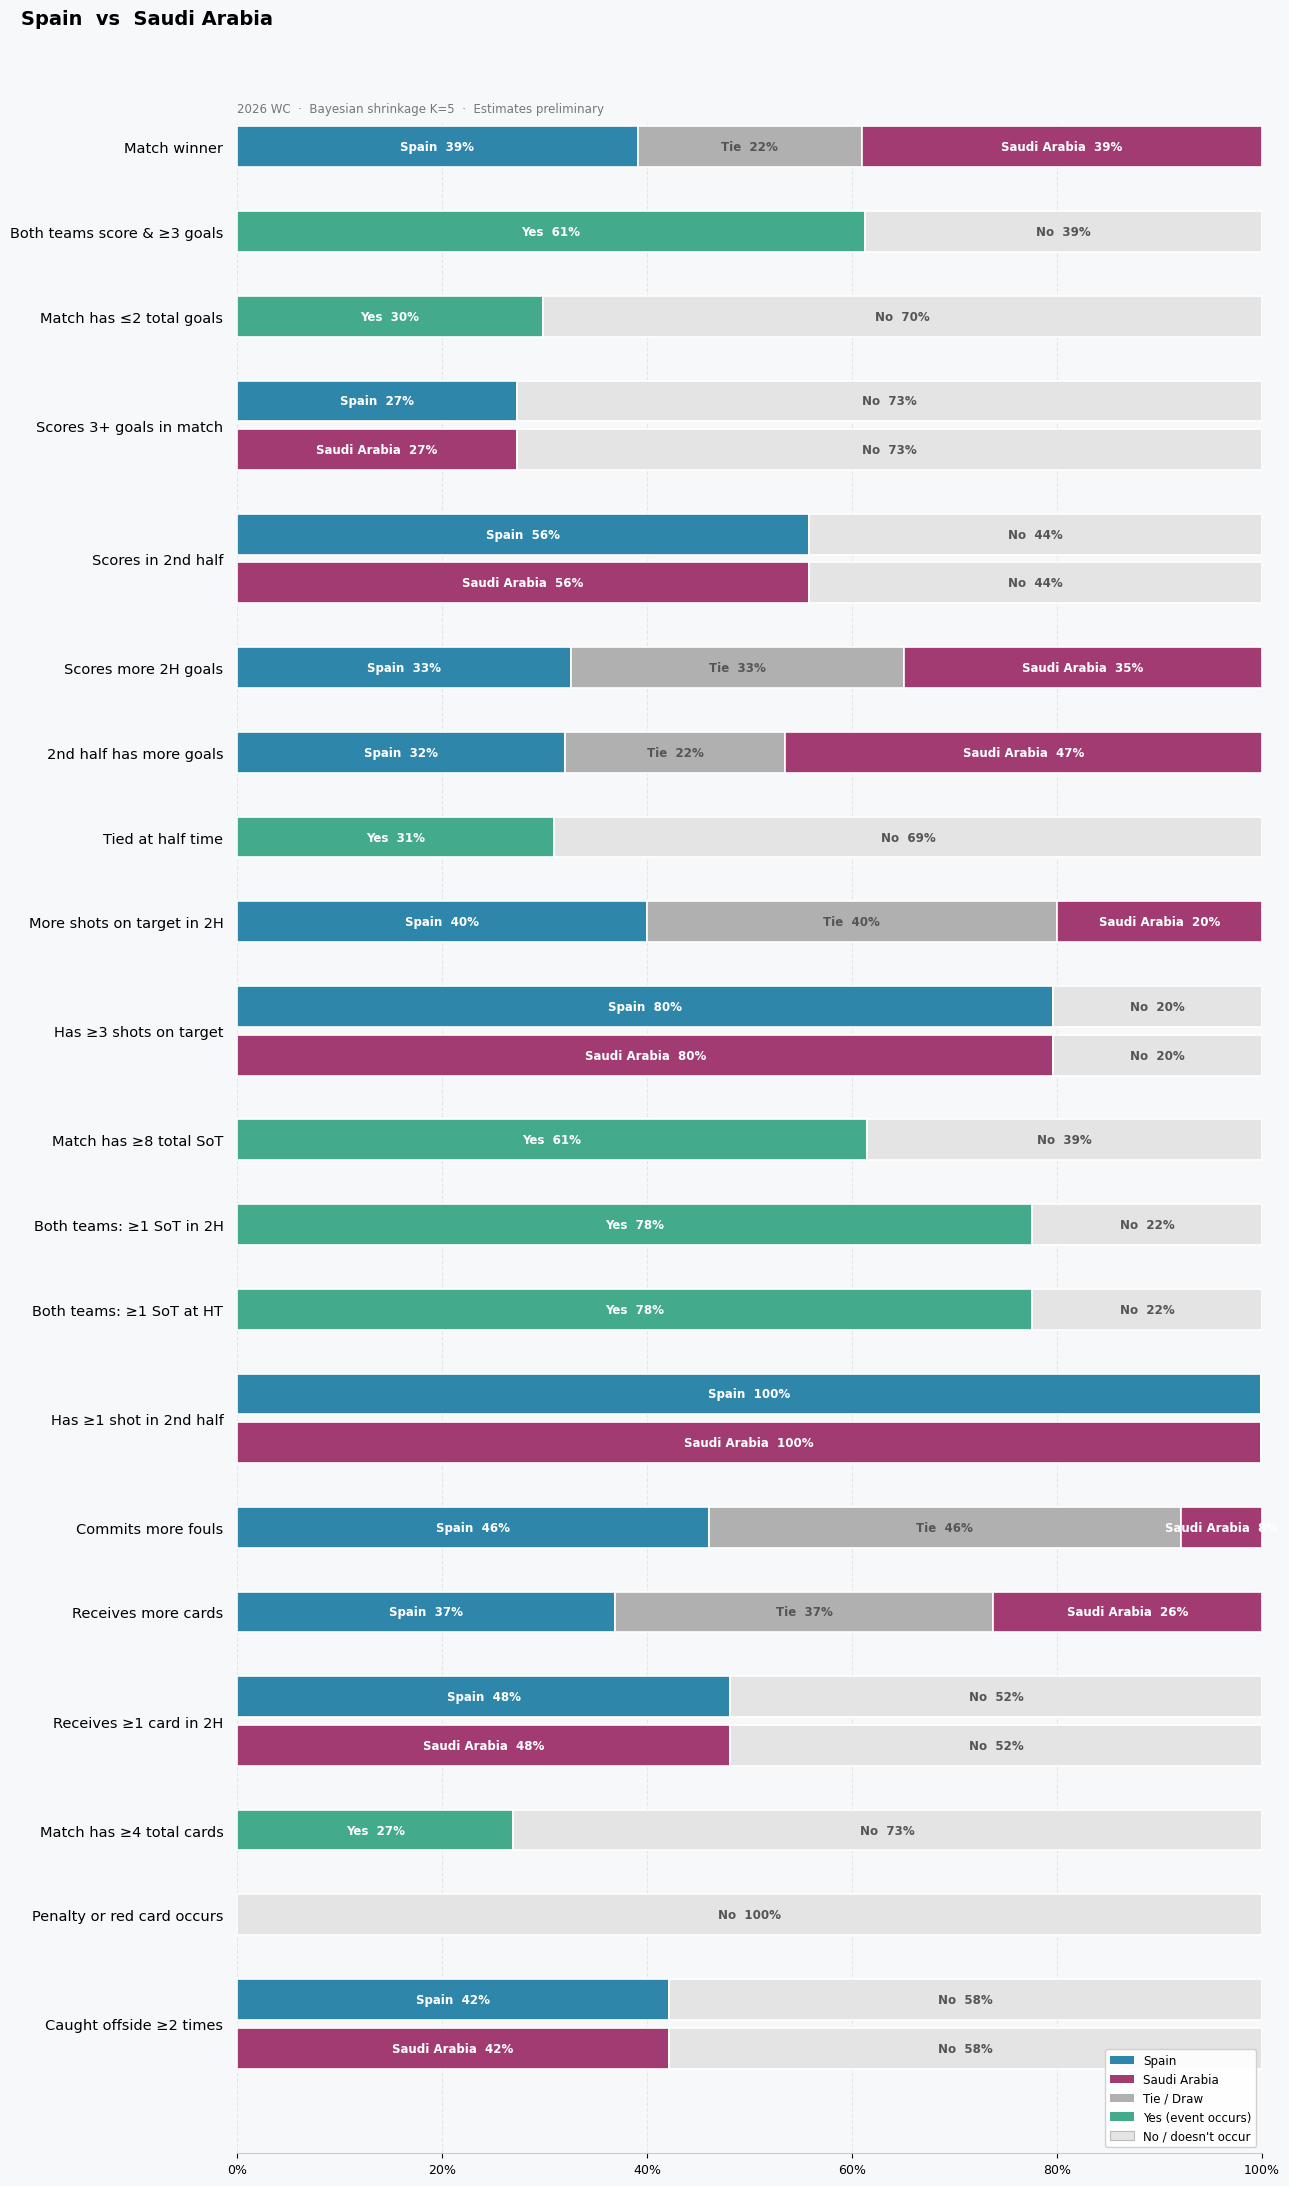

In [28]:
# ── Verification: visual probability report ──────────────────────────────────
# player1 can be a single string or a list of player names.
# Example: plot_predictions("United States", "Uruguay", player1=["Balogun", "Weah"])

plot_predictions("Spain", "Saudi Arabia", player1=[])
